In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
import pandas as pd
import os

# Folder containing all NHANES files
folder_path = r"D:\DermaVision_Module1\dataset\NHANES"

# List of NHANES cycles
cycles = ["F", "G", "H", "I", "J"]

# Store datasets
demo_data = {}
deq_data = {}

# Load all files
for cycle in cycles:

    demo_file = os.path.join(
        folder_path,
        f"DEMO_{cycle}.XPT"
    )

    deq_file = os.path.join(
        folder_path,
        f"DEQ_{cycle}.XPT"
    )

    # Read files
    demo_data[cycle] = pd.read_sas(
        demo_file,
        format="xport"
    )

    deq_data[cycle] = pd.read_sas(
        deq_file,
        format="xport"
    )

print("All NHANES files loaded successfully!")

All NHANES files loaded successfully!


In [6]:
# Check dataset shapes

for cycle in cycles:

    print(f"\nCycle {cycle}")

    print(
        "Demographics shape:",
        demo_data[cycle].shape
    )

    print(
        "Dermatology shape:",
        deq_data[cycle].shape
    )


Cycle F
Demographics shape: (10537, 43)
Dermatology shape: (4145, 9)

Cycle G
Demographics shape: (9756, 48)
Dermatology shape: (3769, 9)

Cycle H
Demographics shape: (10175, 47)
Dermatology shape: (3928, 9)

Cycle I
Demographics shape: (9971, 47)
Dermatology shape: (3818, 9)

Cycle J
Demographics shape: (9254, 46)
Dermatology shape: (3419, 9)


In [7]:
# Print columns of Dermatology Questionnaire
# for every NHANES cycle

for cycle in cycles:

    print("\n" + "=" * 50)
    print(f"Cycle {cycle} - DEQ Columns")
    print("=" * 50)

    print(deq_data[cycle].columns.tolist())


Cycle F - DEQ Columns
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125']

Cycle G - DEQ Columns
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125']

Cycle H - DEQ Columns
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125']

Cycle I - DEQ Columns
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125']

Cycle J - DEQ Columns
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125']


In [8]:
for column in deq_data["F"].columns:

    print("\n" + "=" * 60)
    print(f"Column: {column}")
    print("=" * 60)

    print("Unique values:")
    print(sorted(deq_data["F"][column].dropna().unique()))

    print("\nValue counts:")
    print(deq_data["F"][column].value_counts(dropna=False))


Column: SEQN
Unique values:
[np.float64(51624.0), np.float64(51629.0), np.float64(51630.0), np.float64(51637.0), np.float64(51643.0), np.float64(51647.0), np.float64(51648.0), np.float64(51653.0), np.float64(51655.0), np.float64(51656.0), np.float64(51657.0), np.float64(51658.0), np.float64(51660.0), np.float64(51662.0), np.float64(51664.0), np.float64(51666.0), np.float64(51667.0), np.float64(51670.0), np.float64(51672.0), np.float64(51673.0), np.float64(51674.0), np.float64(51676.0), np.float64(51677.0), np.float64(51683.0), np.float64(51685.0), np.float64(51691.0), np.float64(51692.0), np.float64(51694.0), np.float64(51696.0), np.float64(51697.0), np.float64(51699.0), np.float64(51701.0), np.float64(51702.0), np.float64(51704.0), np.float64(51705.0), np.float64(51708.0), np.float64(51709.0), np.float64(51710.0), np.float64(51711.0), np.float64(51714.0), np.float64(51715.0), np.float64(51718.0), np.float64(51721.0), np.float64(51723.0), np.float64(51724.0), np.float64(51726.0), np.f

In [11]:
# Check the important demographic columns
for cycle in cycles:

    print(f"\nCycle {cycle}")

    print(
        demo_data[cycle][
            ["SEQN", "RIDAGEYR", "RIAGENDR"]
        ].head()
    )


Cycle F
      SEQN  RIDAGEYR  RIAGENDR
0  51624.0      34.0       1.0
1  51625.0       4.0       1.0
2  51626.0      16.0       1.0
3  51627.0      10.0       1.0
4  51628.0      60.0       2.0

Cycle G
      SEQN  RIDAGEYR  RIAGENDR
0  62161.0      22.0       1.0
1  62162.0       3.0       2.0
2  62163.0      14.0       1.0
3  62164.0      44.0       2.0
4  62165.0      14.0       2.0

Cycle H
      SEQN  RIDAGEYR  RIAGENDR
0  73557.0      69.0       1.0
1  73558.0      54.0       1.0
2  73559.0      72.0       1.0
3  73560.0       9.0       1.0
4  73561.0      73.0       2.0

Cycle I
      SEQN  RIDAGEYR  RIAGENDR
0  83732.0      62.0       1.0
1  83733.0      53.0       1.0
2  83734.0      78.0       1.0
3  83735.0      56.0       2.0
4  83736.0      42.0       2.0

Cycle J
      SEQN  RIDAGEYR  RIAGENDR
0  93703.0       2.0       2.0
1  93704.0       2.0       1.0
2  93705.0      66.0       2.0
3  93706.0      18.0       1.0
4  93707.0      13.0       1.0


In [12]:
# Store merged data for all cycles
merged_data = {}

for cycle in cycles:

    # Select only required demographic columns
    demo_selected = demo_data[cycle][
        ["SEQN", "RIDAGEYR", "RIAGENDR"]
    ]

    # Merge Demographics and Dermatology data
    merged_data[cycle] = pd.merge(
        deq_data[cycle],
        demo_selected,
        on="SEQN",
        how="inner"
    )

    print(
        f"Cycle {cycle} merged shape:",
        merged_data[cycle].shape
    )

Cycle F merged shape: (4145, 11)
Cycle G merged shape: (3769, 11)
Cycle H merged shape: (3928, 11)
Cycle I merged shape: (3818, 11)
Cycle J merged shape: (3419, 11)


In [13]:
# Combine all NHANES cycles into one dataset

combined_data = pd.concat(
    [
        merged_data["F"],
        merged_data["G"],
        merged_data["H"],
        merged_data["I"],
        merged_data["J"]
    ],
    ignore_index=True
)

print("Combined dataset shape:", combined_data.shape)

print("\nColumns:")
print(combined_data.columns.tolist())

Combined dataset shape: (19079, 11)

Columns:
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125', 'RIDAGEYR', 'RIAGENDR']


In [14]:
combined_data.head()

,SEQN,DED031,DEQ034A,DEQ034C,DEQ034D,DEQ038G,DEQ038Q,DED120,DED125,RIDAGEYR,RIAGENDR
0,51624.0,5.0,4.0,5.0,5.0,1.0,2.0,3333.0,1.200000e+02,34.0,1.0
1,51629.0,3.0,2.0,1.0,5.0,1.0,1.0,240.0,1.200000e+02,26.0,1.0
2,51630.0,4.0,3.0,4.0,4.0,2.0,NaN,3333.0,1.200000e+02,49.0,2.0
3,51637.0,3.0,3.0,5.0,1.0,1.0,1.0,120.0,3.000000e+02,35.0,2.0
4,51643.0,5.0,5.0,5.0,5.0,2.0,NaN,3333.0,5.397605e-79,42.0,2.0


In [15]:
# Check information about the combined dataset

print("Dataset shape:")
print(combined_data.shape)

print("\nMissing values:")
print(combined_data.isnull().sum())

print("\nData types:")
print(combined_data.dtypes)

Dataset shape:
(19079, 11)

Missing values:
SEQN            0
DED031          4
DEQ034A         4
DEQ034C       190
DEQ034D       190
DEQ038G         4
DEQ038Q     12429
DED120         26
DED125         26
RIDAGEYR        0
RIAGENDR        0
dtype: int64

Data types:
SEQN        float64
DED031      float64
DEQ034A     float64
DEQ034C     float64
DEQ034D     float64
DEQ038G     float64
DEQ038Q     float64
DED120      float64
DED125      float64
RIDAGEYR    float64
RIAGENDR    float64
dtype: object


In [16]:
# Check unique values for every important variable

columns_to_check = [
    "DED031",
    "DEQ034A",
    "DEQ034C",
    "DEQ034D",
    "DEQ038G",
    "DEQ038Q",
    "DED120",
    "DED125",
    "RIAGENDR"
]

for column in columns_to_check:

    print("\n" + "=" * 50)
    print(column)
    print("=" * 50)

    print(
        combined_data[column]
        .value_counts(dropna=False)
        .sort_index()
    )


DED031
DED031
1.0      341
2.0     1457
3.0     4418
4.0     4562
5.0     8058
6.0      196
77.0       1
99.0      42
NaN        4
Name: count, dtype: int64

DEQ034A
DEQ034A
1.0     2162
2.0     4721
3.0     7420
4.0     2782
5.0     1796
6.0      186
99.0       8
NaN        4
Name: count, dtype: int64

DEQ034C
DEQ034C
1.0    1126
2.0    1246
3.0    4181
4.0    3812
5.0    8520
9.0       4
NaN     190
Name: count, dtype: int64

DEQ034D
DEQ034D
1.0    2136
2.0    2257
3.0    3641
4.0    2791
5.0    8061
9.0       3
NaN     190
Name: count, dtype: int64

DEQ038G
DEQ038G
1.0     6650
2.0    12379
9.0       46
NaN        4
Name: count, dtype: int64

DEQ038Q
DEQ038Q
1.0         3482
2.0         1724
3.0          657
4.0          221
5.0          231
6.0           86
7.0           22
8.0           15
9.0            4
10.0         102
11.0           2
12.0          34
15.0          21
20.0          45
99999.0        4
NaN        12429
Name: count, dtype: int64

DED120
DED120
5.397605e-79    

In [17]:
import numpy as np

# Create a copy so the original combined_data remains unchanged
clean_data = combined_data.copy()

# Replace known special response codes with NaN

special_codes = {
    "DED031": [6, 77, 99],
    "DEQ034A": [6, 99],
    "DEQ034C": [9],
    "DEQ034D": [9],
    "DEQ038G": [9],
    "DEQ038Q": [99999],
    "DED120": [3333, 9999],
    "DED125": [3333, 7777, 9999]
}

for column, codes in special_codes.items():
    clean_data[column] = clean_data[column].replace(
        codes,
        np.nan
    )

# Handle the strange extremely small value
clean_data["DED120"] = clean_data["DED120"].replace(
    5.397605e-79,
    np.nan
)

clean_data["DED125"] = clean_data["DED125"].replace(
    5.397605e-79,
    np.nan
)

print("Special codes replaced successfully.")

print("\nMissing values after cleaning:")
print(clean_data.isnull().sum())

Special codes replaced successfully.

Missing values after cleaning:
SEQN            0
DED031        243
DEQ034A       198
DEQ034C       194
DEQ034D       193
DEQ038G        50
DEQ038Q     12433
DED120       2478
DED125        138
RIDAGEYR        0
RIAGENDR        0
dtype: int64


In [18]:
# Check the relationship between
# sunburn occurrence and number of sunburns

sunburn_check = pd.crosstab(
    clean_data["DEQ038G"],
    clean_data["DEQ038Q"],
    dropna=False
)

print(sunburn_check)

DEQ038Q  1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0  \
DEQ038G                                                                     
1.0      3482  1724   657   221   231    86    22    15     4   102     2   
2.0         0     0     0     0     0     0     0     0     0     0     0   
NaN         0     0     0     0     0     0     0     0     0     0     0   

DEQ038Q  12.0  15.0  20.0   NaN   
DEQ038G                           
1.0        34    21    45      4  
2.0         0     0     0  12379  
NaN         0     0     0     50  


In [19]:
# If respondent reported NO sunburn,
# set number of sunburns to 0

clean_data.loc[
    clean_data["DEQ038G"] == 2,
    "DEQ038Q"
] = 0

# Check missing values again
print(
    clean_data[
        ["DEQ038G", "DEQ038Q"]
    ].isnull().sum()
)

DEQ038G    50
DEQ038Q    54
dtype: int64


In [20]:
# Check descriptive statistics for outdoor exposure

print("DED120 - Work/School day outdoor minutes")
print(
    clean_data["DED120"].describe()
)

print("\nDED125 - Non-work day outdoor minutes")
print(
    clean_data["DED125"].describe()
)

print("\nMissing percentages:")

for column in ["DED120", "DED125"]:

    missing_percentage = (
        clean_data[column].isnull().sum()
        / len(clean_data)
        * 100
    )

    print(
        f"{column}: "
        f"{missing_percentage:.2f}%"
    )

DED120 - Work/School day outdoor minutes
count    1.660100e+04
mean     1.047691e+02
std      1.398095e+02
min      5.397605e-79
25%      5.397605e-79
50%      6.000000e+01
75%      1.200000e+02
max      4.800000e+02
Name: DED120, dtype: float64

DED125 - Non-work day outdoor minutes
count    1.894100e+04
mean     1.438025e+02
std      1.262030e+02
min      5.397605e-79
25%      6.000000e+01
50%      1.200000e+02
75%      2.400000e+02
max      4.800000e+02
Name: DED125, dtype: float64

Missing percentages:
DED120: 12.99%
DED125: 0.72%


In [21]:
import numpy as np

# Remove invalid extremely small values
clean_data.loc[
    clean_data["DED120"] < 1e-10,
    "DED120"
] = np.nan

clean_data.loc[
    clean_data["DED125"] < 1e-10,
    "DED125"
] = np.nan

print("DED120 missing:", clean_data["DED120"].isnull().sum())
print("DED125 missing:", clean_data["DED125"].isnull().sum())

DED120 missing: 7878
DED125 missing: 3008


In [22]:
print(clean_data[
    ["DED120", "DED125"]
].describe())

             DED120        DED125
count  11201.000000  16071.000000
mean     155.278279    169.483168
std      145.352423    120.079131
min       14.000000     14.000000
25%       60.000000     60.000000
50%      120.000000    120.000000
75%      240.000000    240.000000
max      480.000000    480.000000


In [23]:
# Fill missing outdoor exposure values using median

clean_data["DED120"] = clean_data["DED120"].fillna(
    clean_data["DED120"].median()
)

clean_data["DED125"] = clean_data["DED125"].fillna(
    clean_data["DED125"].median()
)

print("Missing values after outdoor time imputation:")

print(
    clean_data[
        ["DED120", "DED125"]
    ].isnull().sum()
)

Missing values after outdoor time imputation:
DED120    0
DED125    0
dtype: int64


In [24]:
print(clean_data.isnull().sum())

SEQN          0
DED031      243
DEQ034A     198
DEQ034C     194
DEQ034D     193
DEQ038G      50
DEQ038Q      54
DED120        0
DED125        0
RIDAGEYR      0
RIAGENDR      0
dtype: int64


In [25]:
# Rename NHANES columns to meaningful names

clean_data = clean_data.rename(columns={

    "SEQN": "Participant_ID",

    "RIDAGEYR": "Age",

    "RIAGENDR": "Sex",

    "DED031": "Skin_Sun_Response",

    "DEQ034A": "Shade_Usage",

    "DEQ034C": "Protective_Clothing_Usage",

    "DEQ034D": "Sunscreen_Usage",

    "DEQ038G": "Sunburn_Last_Year",

    "DEQ038Q": "Number_of_Sunburns",

    "DED120": "Outdoor_Time_Work_Days",

    "DED125": "Outdoor_Time_Non_Work_Days"

})

print("Columns renamed successfully!\n")

print(clean_data.columns.tolist())

Columns renamed successfully!

['Participant_ID', 'Skin_Sun_Response', 'Shade_Usage', 'Protective_Clothing_Usage', 'Sunscreen_Usage', 'Sunburn_Last_Year', 'Number_of_Sunburns', 'Outdoor_Time_Work_Days', 'Outdoor_Time_Non_Work_Days', 'Age', 'Sex']


In [26]:
required_columns = [

    "Skin_Sun_Response",
    "Shade_Usage",
    "Protective_Clothing_Usage",
    "Sunscreen_Usage",
    "Sunburn_Last_Year",
    "Number_of_Sunburns",
    "Outdoor_Time_Work_Days",
    "Outdoor_Time_Non_Work_Days",
    "Age",
    "Sex"
]

clean_data = clean_data.dropna(
    subset=required_columns
)

print("Final dataset shape:", clean_data.shape)

Final dataset shape: (18603, 11)


In [27]:
# Check distribution of skin sun response

print(
    clean_data["Skin_Sun_Response"]
    .value_counts()
    .sort_index()
)

Skin_Sun_Response
1.0     333
2.0    1440
3.0    4376
4.0    4517
5.0    7937
Name: count, dtype: int64


In [28]:
# Create 3-class skin sensitivity target

def create_skin_sensitivity(response):

    if response in [1, 2]:
        return "High_Sensitivity"

    elif response == 3:
        return "Moderate_Sensitivity"

    elif response in [4, 5]:
        return "Low_Sensitivity"


clean_data["Skin_Sensitivity"] = (
    clean_data["Skin_Sun_Response"]
    .apply(create_skin_sensitivity)
)

# Check new class distribution
print(
    clean_data["Skin_Sensitivity"]
    .value_counts()
)

Skin_Sensitivity
Low_Sensitivity         12454
Moderate_Sensitivity     4376
High_Sensitivity         1773
Name: count, dtype: int64


In [29]:
# Select input features

feature_columns = [

    "Age",
    "Sex",
    "Shade_Usage",
    "Protective_Clothing_Usage",
    "Sunscreen_Usage",
    "Sunburn_Last_Year",
    "Number_of_Sunburns",
    "Outdoor_Time_Work_Days",
    "Outdoor_Time_Non_Work_Days"
]

# Input features
X = clean_data[feature_columns].copy()

# Target
y = clean_data["Skin_Sensitivity"].copy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Input shape: (18603, 9)
Target shape: (18603,)

Input features:
['Age', 'Sex', 'Shade_Usage', 'Protective_Clothing_Usage', 'Sunscreen_Usage', 'Sunburn_Last_Year', 'Number_of_Sunburns', 'Outdoor_Time_Work_Days', 'Outdoor_Time_Non_Work_Days']

Target distribution:
Skin_Sensitivity
Low_Sensitivity         12454
Moderate_Sensitivity     4376
High_Sensitivity         1773
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
label_encoder = LabelEncoder()

# Convert target labels to numbers
y_encoded = label_encoder.fit_transform(y)

# Show mapping
for index, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} → {index}")

High_Sensitivity → 0
Low_Sensitivity → 1
Moderate_Sensitivity → 2


In [31]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting target distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training data shape: (14882, 9)
Testing data shape: (3721, 9)

Training target distribution:
0    1418
1    9963
2    3501
Name: count, dtype: int64

Testing target distribution:
0     355
1    2491
2     875
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler on testing data
X_test_scaled = scaler.transform(X_test)

print("Training data scaled shape:", X_train_scaled.shape)
print("Testing data scaled shape:", X_test_scaled.shape)

Training data scaled shape: (14882, 9)
Testing data scaled shape: (3721, 9)


In [33]:
print("Training feature means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))

Training feature means:
[-7.54372747e-17 -1.26524543e-17  1.23659836e-16 -8.28377669e-17
  7.30500192e-17 -2.38725553e-18  1.81431420e-17  2.72147130e-17
 -7.59147258e-17]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim


# Define the ANN model

class SkinSensitivityANN(nn.Module):

    def __init__(self):

        super(SkinSensitivityANN, self).__init__()

        self.network = nn.Sequential(

            # First hidden layer
            nn.Linear(9, 64),
            nn.ReLU(),

            # Second hidden layer
            nn.Linear(64, 32),
            nn.ReLU(),

            # Third hidden layer
            nn.Linear(32, 16),
            nn.ReLU(),

            # Output layer
            nn.Linear(16, 3)
        )

    def forward(self, x):

        return self.network(x)


# Create model
model = SkinSensitivityANN()

print(model)

SkinSensitivityANN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=3, bias=True)
  )
)


In [37]:
# Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("X_train tensor shape:", X_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)

print("y_train tensor shape:", y_train_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([14882, 9])
X_test tensor shape: torch.Size([3721, 9])
y_train tensor shape: torch.Size([14882])
y_test tensor shape: torch.Size([3721])


In [38]:
from sklearn.utils.class_weight import compute_class_weight

# Get the unique classes
classes = np.unique(y_train)

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert weights to PyTorch tensor
class_weights = torch.tensor(
    weights,
    dtype=torch.float32
)

print("Classes:", classes)
print("Class weights:", class_weights)

Classes: [0 1 2]
Class weights: tensor([3.4984, 0.4979, 1.4169])


In [39]:
# Loss function with class weights
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [40]:
from torch.utils.data import TensorDataset, DataLoader

# Create PyTorch datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Store training history
train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

# Number of training epochs
epochs = 50

# Training loop
for epoch in range(epochs):

    # Training mode
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in train_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Store loss
        running_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        total_predictions += labels.size(0)

        correct_predictions += (
            predicted == labels
        ).sum().item()

    # Calculate epoch training metrics
    epoch_train_loss = (
        running_loss / len(train_dataset)
    )

    epoch_train_accuracy = (
        correct_predictions / total_predictions
    )

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # -------------------------------
    # Validation / Test evaluation
    # -------------------------------

    model.eval()

    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for inputs, labels in test_loader:

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            test_running_loss += (
                loss.item() * inputs.size(0)
            )

            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)

            test_correct += (
                predicted == labels
            ).sum().item()

    # Calculate validation metrics
    epoch_test_loss = (
        test_running_loss / len(test_dataset)
    )

    epoch_test_accuracy = (
        test_correct / test_total
    )

    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_accuracy)

    # Print progress
    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Accuracy: {epoch_train_accuracy * 100:.2f}% | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Accuracy: {epoch_test_accuracy * 100:.2f}%"
    )

Epoch [1/50] | Train Loss: 1.0118 | Train Accuracy: 54.42% | Test Loss: 0.9527 | Test Accuracy: 59.72%
Epoch [2/50] | Train Loss: 0.9640 | Train Accuracy: 59.47% | Test Loss: 0.9580 | Test Accuracy: 58.83%
Epoch [3/50] | Train Loss: 0.9606 | Train Accuracy: 60.64% | Test Loss: 0.9476 | Test Accuracy: 59.80%
Epoch [4/50] | Train Loss: 0.9564 | Train Accuracy: 60.49% | Test Loss: 0.9493 | Test Accuracy: 61.95%
Epoch [5/50] | Train Loss: 0.9552 | Train Accuracy: 60.42% | Test Loss: 0.9482 | Test Accuracy: 60.39%
Epoch [6/50] | Train Loss: 0.9539 | Train Accuracy: 60.64% | Test Loss: 0.9474 | Test Accuracy: 60.74%
Epoch [7/50] | Train Loss: 0.9519 | Train Accuracy: 60.53% | Test Loss: 0.9499 | Test Accuracy: 61.57%
Epoch [8/50] | Train Loss: 0.9519 | Train Accuracy: 60.69% | Test Loss: 0.9461 | Test Accuracy: 59.34%
Epoch [9/50] | Train Loss: 0.9503 | Train Accuracy: 60.27% | Test Loss: 0.9518 | Test Accuracy: 57.51%
Epoch [10/50] | Train Loss: 0.9495 | Train Accuracy: 60.55% | Test Loss: 

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Put model in evaluation mode
model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    _, y_pred_tensor = torch.max(outputs, 1)

# Convert predictions to NumPy
y_pred = y_pred_tensor.numpy()

# Overall accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Final Model Test Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")
print(cm)

Final Model Test Accuracy: 59.77%

Classification Report:

                      precision    recall  f1-score   support

    High_Sensitivity       0.21      0.47      0.29       355
     Low_Sensitivity       0.84      0.69      0.76      2491
Moderate_Sensitivity       0.39      0.39      0.39       875

            accuracy                           0.60      3721
           macro avg       0.48      0.52      0.48      3721
        weighted avg       0.67      0.60      0.63      3721


Confusion Matrix:

[[ 166   63  126]
 [ 367 1718  406]
 [ 273  262  340]]


In [42]:
from sklearn.model_selection import train_test_split

# -----------------------------------
# First split: 80% Train+Validation
#              20% Final Test
# -----------------------------------

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


# -----------------------------------
# Second split:
# 85% Training
# 15% Validation
# -----------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.15,
    random_state=42,
    stratify=y_train_val
)


print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training shape: (12649, 9)
Validation shape: (2233, 9)
Test shape: (3721, 9)

Training class distribution:
0    1205
1    8468
2    2976
Name: count, dtype: int64

Validation class distribution:
0     213
1    1495
2     525
Name: count, dtype: int64

Test class distribution:
0     355
1    2491
2     875
Name: count, dtype: int64


In [43]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Training: (12649, 9)
Validation: (2233, 9)
Test: (3721, 9)


In [44]:
import torch

# Input tensors

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)


# Target tensors

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)


print("All tensors created successfully.")

All tensors created successfully.


In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
)

print("Class labels:", classes)
print("Class weights:", class_weights)

Class labels: [0 1 2]
Class weights: tensor([3.4990, 0.4979, 1.4168])


In [46]:
import torch.nn as nn
import torch.optim as optim


class ImprovedSkinANN(nn.Module):

    def __init__(self):

        super(ImprovedSkinANN, self).__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(9, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Hidden Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            # Hidden Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output Layer
            nn.Linear(32, 3)
        )


    def forward(self, x):

        return self.network(x)


# Create a fresh model
model = ImprovedSkinANN()

print(model)

ImprovedSkinANN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [48]:
# Weighted loss function

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Adam optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [49]:
from torch.utils.data import TensorDataset, DataLoader
import copy

# Create datasets

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)


# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)


# -----------------------------------
# Training settings
# -----------------------------------

max_epochs = 100
patience = 10

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0


# Store history for graphs

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


# -----------------------------------
# Training Loop
# -----------------------------------

for epoch in range(max_epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for inputs, labels in train_loader:

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()


        # Store loss
        running_loss += (
            loss.item() * inputs.size(0)
        )


        # Predictions
        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    epoch_train_loss = (
        running_loss / len(train_dataset)
    )

    epoch_train_accuracy = (
        correct / total
    )


    train_losses.append(
        epoch_train_loss
    )

    train_accuracies.append(
        epoch_train_accuracy
    )


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() * inputs.size(0)
            )


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    epoch_val_loss = (
        val_running_loss / len(val_dataset)
    )

    epoch_val_accuracy = (
        val_correct / val_total
    )


    val_losses.append(
        epoch_val_loss
    )

    val_accuracies.append(
        epoch_val_accuracy
    )


    # =========================
    # EARLY STOPPING
    # =========================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1


    # Print progress

    print(
        f"Epoch [{epoch + 1}/{max_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy * 100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy * 100:.2f}%"
    )


    # Stop if validation loss
    # has not improved

    if patience_counter >= patience:

        print(
            f"\nEarly stopping triggered at epoch "
            f"{epoch + 1}"
        )

        break


# -----------------------------------
# Restore the best model
# -----------------------------------

model.load_state_dict(
    best_model_state
)

print("\nBest model restored!")
print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)

Epoch [1/100] | Train Loss: 0.9985 | Train Acc: 57.59% | Val Loss: 0.9589 | Val Acc: 59.29%
Epoch [2/100] | Train Loss: 0.9714 | Train Acc: 59.35% | Val Loss: 0.9525 | Val Acc: 60.32%
Epoch [3/100] | Train Loss: 0.9719 | Train Acc: 59.63% | Val Loss: 0.9500 | Val Acc: 60.95%
Epoch [4/100] | Train Loss: 0.9683 | Train Acc: 59.60% | Val Loss: 0.9534 | Val Acc: 57.95%
Epoch [5/100] | Train Loss: 0.9617 | Train Acc: 60.52% | Val Loss: 0.9471 | Val Acc: 61.58%
Epoch [6/100] | Train Loss: 0.9618 | Train Acc: 60.58% | Val Loss: 0.9573 | Val Acc: 57.28%
Epoch [7/100] | Train Loss: 0.9628 | Train Acc: 60.32% | Val Loss: 0.9461 | Val Acc: 59.56%
Epoch [8/100] | Train Loss: 0.9634 | Train Acc: 59.78% | Val Loss: 0.9472 | Val Acc: 61.40%
Epoch [9/100] | Train Loss: 0.9593 | Train Acc: 60.11% | Val Loss: 0.9476 | Val Acc: 60.55%
Epoch [10/100] | Train Loss: 0.9632 | Train Acc: 60.62% | Val Loss: 0.9441 | Val Acc: 60.28%
Epoch [11/100] | Train Loss: 0.9586 | Train Acc: 59.81% | Val Loss: 0.9496 | Va

In [50]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Put the best model in evaluation mode
model.eval()

# Make predictions on the untouched test set
with torch.no_grad():

    outputs = model(X_test_tensor)

    _, y_pred_tensor = torch.max(
        outputs,
        1
    )

# Convert predictions to NumPy
y_pred = y_pred_tensor.cpu().numpy()


# -----------------------------------
# Final Test Accuracy
# -----------------------------------

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


# -----------------------------------
# Classification Report
# -----------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# -----------------------------------
# Confusion Matrix
# -----------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")

print(cm)

Final Test Accuracy: 60.58%

Classification Report:

                      precision    recall  f1-score   support

    High_Sensitivity       0.26      0.50      0.34       355
     Low_Sensitivity       0.85      0.68      0.75      2491
Moderate_Sensitivity       0.37      0.45      0.41       875

            accuracy                           0.61      3721
           macro avg       0.49      0.54      0.50      3721
        weighted avg       0.68      0.61      0.63      3721


Confusion Matrix:

[[ 176   60  119]
 [ 269 1688  534]
 [ 244  241  390]]


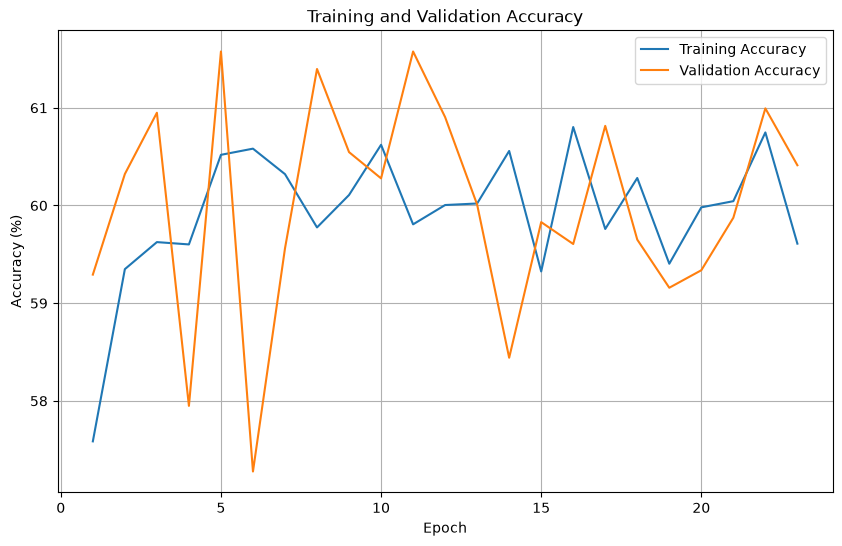

In [51]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    [accuracy * 100 for accuracy in train_accuracies],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    [accuracy * 100 for accuracy in val_accuracies],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

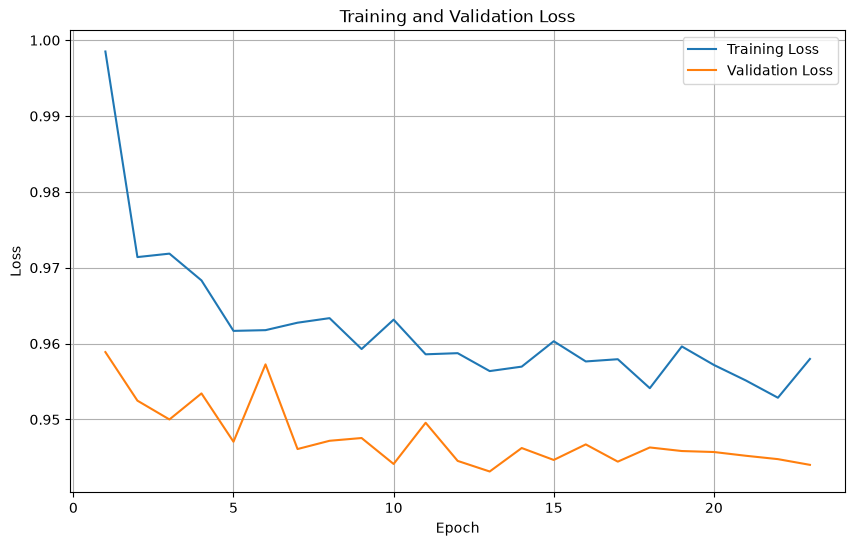

In [52]:
# Epoch numbers
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

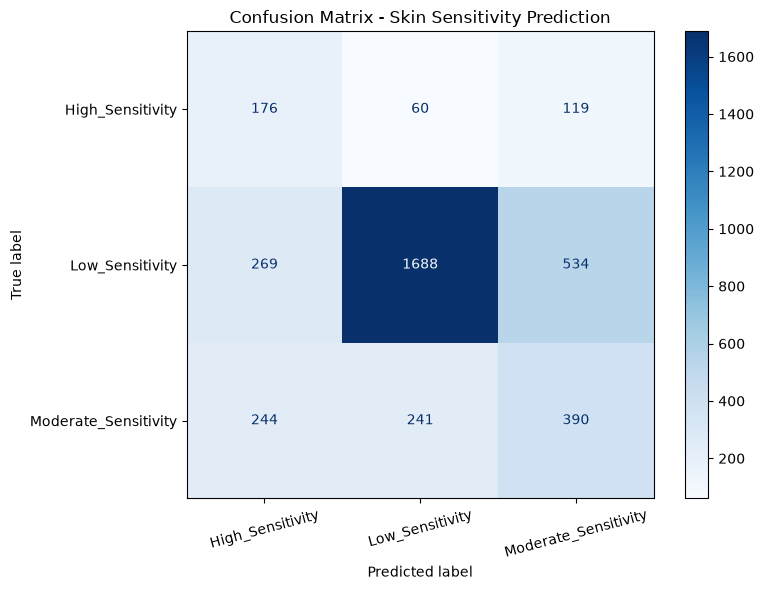

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Class names
class_names = label_encoder.classes_

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Skin Sensitivity Prediction")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [54]:
import torch
import joblib
import os

# Create folder for saved model
os.makedirs("saved_model", exist_ok=True)

# Save PyTorch model
torch.save(
    model.state_dict(),
    "saved_model/skin_sensitivity_model.pth"
)

# Save scaler
joblib.dump(
    scaler,
    "saved_model/scaler.pkl"
)

# Save label encoder
joblib.dump(
    label_encoder,
    "saved_model/label_encoder.pkl"
)

print("Model and preprocessing files saved successfully!")

Model and preprocessing files saved successfully!


In [55]:
##########TEST

In [56]:
# -----------------------------------
# Test the complete prediction pipeline
# -----------------------------------

# Example participant data
sample_input = pd.DataFrame([{
    
    "Shade_Usage": 3,
    "Protective_Clothing_Usage": 3,
    "Sunscreen_Usage": 4,
    "Sunburn_Last_Year": 1,
    "Number_of_Sunburns": 2,
    "Outdoor_Time_Work_Days": 120,
    "Outdoor_Time_Non_Work_Days": 180,
    "Age": 22,
    "Sex": 1
}])

print("Sample Input:")
print(sample_input)

Sample Input:
   Shade_Usage  Protective_Clothing_Usage  Sunscreen_Usage  Sunburn_Last_Year  \
0            3                          3                4                  1   

   Number_of_Sunburns  Outdoor_Time_Work_Days  Outdoor_Time_Non_Work_Days  \
0                   2                     120                         180   

   Age  Sex  
0   22    1  


In [58]:
print("Scaler expects:", scaler.n_features_in_, "features")

print("\nFeature names used by scaler:")
print(scaler.feature_names_in_)

print("\nCurrent sample features:")
print(sample_input.columns.tolist())

print("\nNumber of sample features:")
print(sample_input.shape[1])

Scaler expects: 9 features

Feature names used by scaler:
['Age' 'Sex' 'Shade_Usage' 'Protective_Clothing_Usage' 'Sunscreen_Usage'
 'Sunburn_Last_Year' 'Number_of_Sunburns' 'Outdoor_Time_Work_Days'
 'Outdoor_Time_Non_Work_Days']

Current sample features:
['Shade_Usage', 'Protective_Clothing_Usage', 'Sunscreen_Usage', 'Sunburn_Last_Year', 'Number_of_Sunburns', 'Outdoor_Time_Work_Days', 'Outdoor_Time_Non_Work_Days', 'Age', 'Sex']

Number of sample features:
9


In [59]:
# Put sample features in the EXACT order used during training

sample_input = sample_input[
    scaler.feature_names_in_
]

print(sample_input)

   Age  Sex  Shade_Usage  Protective_Clothing_Usage  Sunscreen_Usage  \
0   22    1            3                          3                4   

   Sunburn_Last_Year  Number_of_Sunburns  Outdoor_Time_Work_Days  \
0                  1                   2                     120   

   Outdoor_Time_Non_Work_Days  
0                         180  


In [60]:
# Scale the input
sample_scaled = scaler.transform(sample_input)

# Convert to PyTorch tensor
sample_tensor = torch.tensor(
    sample_scaled,
    dtype=torch.float32
)

print("Input prepared successfully!")
print("Tensor shape:", sample_tensor.shape)

Input prepared successfully!
Tensor shape: torch.Size([1, 9])


In [61]:
# Set model to evaluation mode
model.eval()

with torch.no_grad():
    
    output = model(sample_tensor)
    
    _, predicted_class = torch.max(output, 1)


# Convert numerical prediction back to label
prediction = label_encoder.inverse_transform(
    predicted_class.cpu().numpy()
)

print("Predicted Skin Sensitivity:", prediction[0])

Predicted Skin Sensitivity: Moderate_Sensitivity


In [2]:
import pandas as pd
import os

In [3]:
print(os.getcwd())
print(os.listdir())

D:\DermaVision_Module1\notebooks
['.ipynb_checkpoints', 'ISIC_2019_ANN.ipynb', 'NANHES_ANN_Model.ipynb', 'PAD_UFES_20_ANN.ipynb', 'saved_model', 'Trial_4_SCIN.ipynb', 'Trial_5_UQ_Longitudinal.ipynb']


In [4]:
dataset_path = os.path.join(
    os.path.dirname(os.getcwd()),
    "dataset"
)

print("Dataset folder:", dataset_path)
print("\nContents:")
print(os.listdir(dataset_path))

Dataset folder: D:\DermaVision_Module1\dataset

Contents:
['ISIC_2019', 'NHANES', 'PAD_UFES_20', 'SCIN', 'UQ_Longitudinal']


In [5]:
nhanes_path = os.path.join(dataset_path, "NHANES")

print("NHANES folder:")
print(os.listdir(nhanes_path))

NHANES folder:
['DEMO_F.XPT', 'DEMO_G.XPT', 'DEMO_H.XPT', 'DEMO_I.XPT', 'DEMO_J.XPT', 'DEQ_F.XPT', 'DEQ_G.XPT', 'DEQ_H.XPT', 'DEQ_I.XPT', 'DEQ_J.XPT']


In [7]:
demo_f = pd.read_sas(
    os.path.join(nhanes_path, "DEMO_F.XPT"),
    format="xport"
)

print("Shape:", demo_f.shape)
print("\nColumns:")
print(demo_f.columns.tolist())

Shape: (10537, 43)

Columns:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'DMQMILIT', 'DMDBORN2', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'RIDEXPRG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBR2', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANG', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']


In [8]:
deq_f = pd.read_sas(
    os.path.join(nhanes_path, "DEQ_F.XPT"),
    format="xport"
)

print("Shape:", deq_f.shape)

print("\nColumns:")
print(deq_f.columns.tolist())

Shape: (4145, 9)

Columns:
['SEQN', 'DED031', 'DEQ034A', 'DEQ034C', 'DEQ034D', 'DEQ038G', 'DEQ038Q', 'DED120', 'DED125']


In [9]:
nhanes_f = demo_f.merge(
    deq_f,
    on="SEQN",
    how="inner"
)

print("Merged shape:", nhanes_f.shape)

print("\nFirst 5 rows:")
display(nhanes_f.head())

Merged shape: (4145, 51)

First 5 rows:


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,SDMVPSU,SDMVSTRA,DED031,DEQ034A,DEQ034C,DEQ034D,DEQ038G,DEQ038Q,DED120,DED125
0,51624.0,6.0,2.0,1.0,1.0,34.0,409.0,410.0,3.0,2.0,...,1.0,83.0,5.0,4.0,5.0,5.0,1.0,2.0,3333.0,1.200000e+02
1,51629.0,6.0,2.0,1.0,1.0,26.0,313.0,313.0,1.0,2.0,...,1.0,88.0,3.0,2.0,1.0,5.0,1.0,1.0,240.0,1.200000e+02
2,51630.0,6.0,2.0,1.0,2.0,49.0,596.0,596.0,3.0,2.0,...,2.0,85.0,4.0,3.0,4.0,4.0,2.0,NaN,3333.0,1.200000e+02
3,51637.0,6.0,1.0,NaN,2.0,35.0,431.0,NaN,3.0,2.0,...,2.0,77.0,3.0,3.0,5.0,1.0,1.0,1.0,120.0,3.000000e+02
4,51643.0,6.0,2.0,1.0,2.0,42.0,514.0,516.0,4.0,2.0,...,2.0,75.0,5.0,5.0,5.0,5.0,2.0,NaN,3333.0,5.397605e-79


In [10]:
deq_columns = [
    "DED031",
    "DEQ034A",
    "DEQ034C",
    "DEQ034D",
    "DEQ038G",
    "DEQ038Q",
    "DED120",
    "DED125"
]

for column in deq_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(nhanes_f[column].value_counts(dropna=False).sort_index())


DED031
DED031
1.0       69
2.0      326
3.0     1000
4.0      865
5.0     1834
6.0       37
99.0      13
NaN        1
Name: count, dtype: int64

DEQ034A
DEQ034A
1.0      468
2.0      932
3.0     1518
4.0      643
5.0      556
6.0       24
99.0       3
NaN        1
Name: count, dtype: int64

DEQ034C
DEQ034C
1.0     234
2.0     230
3.0     750
4.0     737
5.0    2167
9.0       2
NaN      25
Name: count, dtype: int64

DEQ034D
DEQ034D
1.0     511
2.0     456
3.0     715
4.0     500
5.0    1936
9.0       2
NaN      25
Name: count, dtype: int64

DEQ038G
DEQ038G
1.0    1495
2.0    2639
9.0      10
NaN       1
Name: count, dtype: int64

DEQ038Q
DEQ038Q
1.0         796
2.0         377
3.0         152
4.0          53
5.0          40
6.0          20
7.0           8
8.0           4
9.0           3
10.0         19
11.0          1
12.0         11
15.0          2
20.0          7
99999.0       2
NaN        2650
Name: count, dtype: int64

DED120
DED120
5.397605e-79    1219
1.400000e+01      86
1.50000

In [12]:
risk_columns = [
    "DED031",   # Skin response to sun
    "DEQ038G",  # Sunburn in past year
    "DEQ038Q",  # Number of sunburns
    "DEQ034A",  # Shade usage
    "DEQ034C",  # Protective clothing
    "DEQ034D",  # Sunscreen usage
    "DED120",   # Outdoor time - work days
    "DED125"    # Outdoor time - non-work days
]

print(nhanes_f[risk_columns].describe(include="all"))

            DED031      DEQ038G       DEQ038Q      DEQ034A      DEQ034C  \
count  4144.000000  4144.000000   1495.000000  4144.000000  4120.000000   
mean      4.309846     1.656129    135.888963     3.059604     4.064320   
std       5.422843     0.600704   3656.247299     2.844437     1.204503   
min       1.000000     1.000000      1.000000     1.000000     1.000000   
25%       3.000000     1.000000      1.000000     2.000000     3.000000   
50%       4.000000     2.000000      1.000000     3.000000     5.000000   
75%       5.000000     2.000000      2.000000     4.000000     5.000000   
max      99.000000     9.000000  99999.000000    99.000000     9.000000   

           DEQ034D        DED120        DED125  
count  4120.000000  4.140000e+03  4.140000e+03  
mean      3.705340  6.182986e+02  1.853488e+02  
std       1.458854  1.218104e+03  5.391808e+02  
min       1.000000  5.397605e-79  5.397605e-79  
25%       3.000000  5.397605e-79  6.000000e+01  
50%       4.000000  6.000000e+

In [13]:
nhanes_f[
    (nhanes_f["DED120"] < 1e-50) |
    (nhanes_f["DED125"] < 1e-50)
][["SEQN", "DED120", "DED125"]].head(20)

,SEQN,DED120,DED125
4,51643.0,3.333000e+03,5.397605e-79
7,51653.0,5.397605e-79,1.200000e+02
11,51658.0,5.397605e-79,6.000000e+01
12,51660.0,5.397605e-79,5.397605e-79
14,51664.0,5.397605e-79,1.200000e+02
22,51677.0,5.397605e-79,3.000000e+02
26,51692.0,5.397605e-79,6.000000e+01
28,51696.0,5.397605e-79,5.397605e-79
29,51697.0,5.397605e-79,1.800000e+02
36,51709.0,3.333000e+03,5.397605e-79


In [14]:
nhanes_f[
    (nhanes_f["DED120"] < 1e-50) |
    (nhanes_f["DED125"] < 1e-50)
][["SEQN", "DED120", "DED125"]].head(20)

,SEQN,DED120,DED125
4,51643.0,3.333000e+03,5.397605e-79
7,51653.0,5.397605e-79,1.200000e+02
11,51658.0,5.397605e-79,6.000000e+01
12,51660.0,5.397605e-79,5.397605e-79
14,51664.0,5.397605e-79,1.200000e+02
22,51677.0,5.397605e-79,3.000000e+02
26,51692.0,5.397605e-79,6.000000e+01
28,51696.0,5.397605e-79,5.397605e-79
29,51697.0,5.397605e-79,1.800000e+02
36,51709.0,3.333000e+03,5.397605e-79


In [15]:
for column in ["DED120", "DED125"]:
    print(f"\n{column}")
    print("Tiny-value artifact:", (nhanes_f[column] < 1e-50).sum())
    print("3333:", (nhanes_f[column] == 3333).sum())
    print("9999:", (nhanes_f[column] == 9999).sum())
    print("Missing:", nhanes_f[column].isna().sum())
    


DED120
Tiny-value artifact: 1219
3333: 640
9999: 5
Missing: 5

DED125
Tiny-value artifact: 630
3333: 17
9999: 10
Missing: 5


In [16]:
import numpy as np

for column in ["DED120", "DED125"]:

    # Convert tiny floating-point artifact to actual zero
    nhanes_f.loc[
        nhanes_f[column].abs() < 1e-50,
        column
    ] = 0

    # Special / non-numeric responses → missing
    nhanes_f.loc[
        nhanes_f[column].isin([3333, 9999]),
        column
    ] = np.nan

print("DED120 missing:", nhanes_f["DED120"].isna().sum())
print("DED125 missing:", nhanes_f["DED125"].isna().sum())

print("\nDED120 unique suspicious values:")
print(nhanes_f["DED120"].sort_values().tail())

print("\nDED125 unique suspicious values:")
print(nhanes_f["DED125"].sort_values().tail())

DED120 missing: 650
DED125 missing: 32

DED120 unique suspicious values:
4127   NaN
4129   NaN
4135   NaN
4139   NaN
4143   NaN
Name: DED120, dtype: float64

DED125 unique suspicious values:
3136   NaN
3462   NaN
3517   NaN
3853   NaN
4088   NaN
Name: DED125, dtype: float64


In [17]:
# Clean NHANES special/missing codes

# DED031 and DEQ034A: 99 = missing/unknown
nhanes_f["DED031"] = nhanes_f["DED031"].replace(99, np.nan)
nhanes_f["DEQ034A"] = nhanes_f["DEQ034A"].replace(99, np.nan)

# DEQ034C and DEQ034D: 9 = missing/unknown
nhanes_f["DEQ034C"] = nhanes_f["DEQ034C"].replace(9, np.nan)
nhanes_f["DEQ034D"] = nhanes_f["DEQ034D"].replace(9, np.nan)

# DEQ038G: 9 = missing/unknown
nhanes_f["DEQ038G"] = nhanes_f["DEQ038G"].replace(9, np.nan)

# DEQ038Q: 99999 = missing/unknown
nhanes_f["DEQ038Q"] = nhanes_f["DEQ038Q"].replace(99999, np.nan)

print("Missing values after cleaning:\n")

print(
    nhanes_f[
        [
            "DED031",
            "DEQ034A",
            "DEQ034C",
            "DEQ034D",
            "DEQ038G",
            "DEQ038Q",
            "DED120",
            "DED125"
        ]
    ].isnull().sum()
)

Missing values after cleaning:

DED031       14
DEQ034A       4
DEQ034C      27
DEQ034D      27
DEQ038G      11
DEQ038Q    2652
DED120      650
DED125       32
dtype: int64


In [18]:
print(
    pd.crosstab(
        nhanes_f["DEQ038G"],
        nhanes_f["DEQ038Q"].isna(),
        margins=True
    )
)

DEQ038Q  False  True   All
DEQ038G                   
1.0       1493     2  1495
2.0          0  2639  2639
All       1493  2641  4134


In [19]:
# Fill sunburn count with 0 only when participant reported no sunburn

nhanes_f.loc[
    (nhanes_f["DEQ038G"] == 2) &
    (nhanes_f["DEQ038Q"].isna()),
    "DEQ038Q"
] = 0

print(
    pd.crosstab(
        nhanes_f["DEQ038G"],
        nhanes_f["DEQ038Q"].isna(),
        margins=True
    )
)

DEQ038Q  False  True   All
DEQ038G                   
1.0       1493     2  1495
2.0       2639     0  2639
All       4132     2  4134


In [20]:
nhanes_f.loc[
    (nhanes_f["DEQ038G"] == 1) &
    (nhanes_f["DEQ038Q"].isna()),
    ["SEQN", "DEQ038G", "DEQ038Q"]
]

,SEQN,DEQ038G,DEQ038Q
668,53356.0,1.0,NaN
2462,57832.0,1.0,NaN


In [21]:
core_columns = [
    "RIAGENDR",
    "RIDAGEYR",
    "DED031",
    "DEQ034A",
    "DEQ034C",
    "DEQ034D",
    "DEQ038G",
    "DEQ038Q",
    "DED120",
    "DED125"
]

print("Total participants:", len(nhanes_f))

print(
    "Complete participants for core features:",
    nhanes_f[core_columns].dropna().shape[0]
)

print(
    "Participants with at least one missing core feature:",
    nhanes_f[core_columns].isna().any(axis=1).sum()
)

Total participants: 4145
Complete participants for core features: 3442
Participants with at least one missing core feature: 703


In [22]:
missing_by_core_feature = (
    nhanes_f[core_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_by_core_feature)

DED120      650
DED125       32
DEQ034D      27
DEQ034C      27
DED031       14
DEQ038Q      13
DEQ038G      11
DEQ034A       4
RIDAGEYR      0
RIAGENDR      0
dtype: int64


In [23]:
other_core_columns = [
    "RIAGENDR",
    "RIDAGEYR",
    "DED031",
    "DEQ034A",
    "DEQ034C",
    "DEQ034D",
    "DEQ038G",
    "DEQ038Q",
    "DED125"
]

missing_ded120 = nhanes_f["DED120"].isna()

print("Rows with missing DED120:", missing_ded120.sum())

print(
    "Among them, complete in all other core features:",
    nhanes_f.loc[
        missing_ded120,
        other_core_columns
    ].dropna().shape[0]
)

Rows with missing DED120: 650
Among them, complete in all other core features: 624


In [24]:
nhanes_f["Work_Day_Outdoor_Time_Available"] = (
    nhanes_f["DED120"].notna()
).astype(int)

print(
    nhanes_f["Work_Day_Outdoor_Time_Available"]
    .value_counts()
)

Work_Day_Outdoor_Time_Available
1    3495
0     650
Name: count, dtype: int64


In [25]:
small_missing_columns = [
    "DED031",
    "DEQ034A",
    "DEQ034C",
    "DEQ034D",
    "DEQ038G",
    "DEQ038Q"
]

nhanes_clean = nhanes_f.dropna(
    subset=small_missing_columns
).copy()

print("Original rows:", len(nhanes_f))
print("Rows after cleaning small missing values:", len(nhanes_clean))
print("Rows removed:", len(nhanes_f) - len(nhanes_clean))

print("\nRemaining missing values:")
print(
    nhanes_clean[
        small_missing_columns
    ].isnull().sum()
)

Original rows: 4145
Rows after cleaning small missing values: 4094
Rows removed: 51

Remaining missing values:
DED031     0
DEQ034A    0
DEQ034C    0
DEQ034D    0
DEQ038G    0
DEQ038Q    0
dtype: int64


In [26]:
print("DED120 missing:", nhanes_clean["DED120"].isna().sum())
print("DED125 missing:", nhanes_clean["DED125"].isna().sum())

print("\nAvailability indicator:")
print(
    nhanes_clean["Work_Day_Outdoor_Time_Available"]
    .value_counts()
)


DED120 missing: 630
DED125 missing: 28

Availability indicator:
Work_Day_Outdoor_Time_Available
1    3464
0     630
Name: count, dtype: int64


In [27]:
nhanes_final = pd.DataFrame({
    
    "Participant_ID": nhanes_clean["SEQN"].astype(str),

    "Age": nhanes_clean["RIDAGEYR"],

    "Sex": nhanes_clean["RIAGENDR"].map({
        1: "Male",
        2: "Female"
    }),

    "Skin_Sun_Response": nhanes_clean["DED031"],

    "Shade_Usage": nhanes_clean["DEQ034A"],

    "Protective_Clothing_Usage": nhanes_clean["DEQ034C"],

    "Sunscreen_Usage": nhanes_clean["DEQ034D"],

    "Sunburn_Last_Year": nhanes_clean["DEQ038G"],

    "Number_of_Sunburns": nhanes_clean["DEQ038Q"],

    "Outdoor_Time_Work_Days": nhanes_clean["DED120"],

    "Work_Day_Outdoor_Time_Available":
        nhanes_clean["Work_Day_Outdoor_Time_Available"],

    "Outdoor_Time_Non_Work_Days": nhanes_clean["DED125"],

    "Source_Dataset": "NHANES"
})

print("Final NHANES shape:", nhanes_final.shape)

print("\nColumns:")
print(nhanes_final.columns.tolist())

print("\nMissing values:")
print(nhanes_final.isnull().sum())


Final NHANES shape: (4094, 13)

Columns:
['Participant_ID', 'Age', 'Sex', 'Skin_Sun_Response', 'Shade_Usage', 'Protective_Clothing_Usage', 'Sunscreen_Usage', 'Sunburn_Last_Year', 'Number_of_Sunburns', 'Outdoor_Time_Work_Days', 'Work_Day_Outdoor_Time_Available', 'Outdoor_Time_Non_Work_Days', 'Source_Dataset']

Missing values:
Participant_ID                       0
Age                                  0
Sex                                  0
Skin_Sun_Response                    0
Shade_Usage                          0
Protective_Clothing_Usage            0
Sunscreen_Usage                      0
Sunburn_Last_Year                    0
Number_of_Sunburns                   0
Outdoor_Time_Work_Days             630
Work_Day_Outdoor_Time_Available      0
Outdoor_Time_Non_Work_Days          28
Source_Dataset                       0
dtype: int64
